In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [309]:
df = pd.read_csv("../raw/maharashtra_prices.csv")


In [310]:
df

,report_date,state_id,state_name,market_id,market_name,commodity_id,commodity_name,total_arrivals,market_center,arrivals,unit_of_arrivals,variety,grade,min_price,max_price,modal_price,unit_of_price
0,2021-01-01,20,Maharashtra,1349,APMC Chimur,15,Cotton,192.0,APMC Chimur,192.0,Metric Tonnes,Other,FAQ,5550.0,5625.0,5575.0,Rs./Quintal
1,2021-01-01,20,Maharashtra,1349,APMC Chimur,2,Paddy(Common),48.0,APMC Chimur,48.0,Metric Tonnes,Other,FAQ,2150.0,2250.0,2175.0,Rs./Quintal
2,2021-01-01,20,Maharashtra,1933,APMC Rajura,13,Soyabean,14.0,APMC Rajura,14.0,Metric Tonnes,Yellow,FAQ,3895.0,4210.0,4095.0,Rs./Quintal
3,2021-01-01,20,Maharashtra,2048,APMC Aarni,45,Red gram/Arhar/Tur(whole),14.0,APMC Aarni,14.0,Metric Tonnes,Other,FAQ,5500.0,5800.0,5600.0,Rs./Quintal
4,2021-01-01,20,Maharashtra,1901,APMC Aatpadi,160,Pomegranate,50.0,APMC Aatpadi,50.0,Metric Tonnes,Other,FAQ,2000.0,40000.0,21000.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967776,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),131,Cucumbar(Kheera),1.2,Pune(Pimpri),1.2,Metric Tonnes,Other,Local,1400.0,2200.0,1800.0,Rs./Quintal
1967777,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),23,Onion,3.3,Pune(Pimpri),3.3,Metric Tonnes,Local,Local,2500.0,4700.0,3600.0,Rs./Quintal
1967778,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),133,Raddish,600.0,Pune(Pimpri),600.0,Metric Tonnes,Other,Local,7.0,9.0,8.0,Rs./Quintal
1967779,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),290,Spinach,650.0,Pune(Pimpri),650.0,Metric Tonnes,Other,Local,7.0,9.0,8.0,Rs./Quintal


In [311]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967781 entries, 0 to 1967780
Data columns (total 17 columns):
 #   Column            Dtype  
---  ------            -----  
 0   report_date       object 
 1   state_id          int64  
 2   state_name        object 
 3   market_id         int64  
 4   market_name       object 
 5   commodity_id      int64  
 6   commodity_name    object 
 7   total_arrivals    float64
 8   market_center     object 
 9   arrivals          float64
 10  unit_of_arrivals  object 
 11  variety           object 
 12  grade             object 
 13  min_price         float64
 14  max_price         float64
 15  modal_price       float64
 16  unit_of_price     object 
dtypes: float64(5), int64(3), object(9)
memory usage: 255.2+ MB


In [312]:
df.isnull().sum()

report_date           0
state_id              0
state_name            0
market_id             0
market_name           0
commodity_id          0
commodity_name        0
total_arrivals        0
market_center         0
arrivals              0
unit_of_arrivals      0
variety               0
grade                 0
min_price            46
max_price             0
modal_price         374
unit_of_price         0
dtype: int64

In [313]:
df.shape

(1967781, 17)

In [314]:
df.dtypes

report_date          object
state_id              int64
state_name           object
market_id             int64
market_name          object
commodity_id          int64
commodity_name       object
total_arrivals      float64
market_center        object
arrivals            float64
unit_of_arrivals     object
variety              object
grade                object
min_price           float64
max_price           float64
modal_price         float64
unit_of_price        object
dtype: object

In [315]:
df.head()

,report_date,state_id,state_name,market_id,market_name,commodity_id,commodity_name,total_arrivals,market_center,arrivals,unit_of_arrivals,variety,grade,min_price,max_price,modal_price,unit_of_price
0,2021-01-01,20,Maharashtra,1349,APMC Chimur,15,Cotton,192.0,APMC Chimur,192.0,Metric Tonnes,Other,FAQ,5550.0,5625.0,5575.0,Rs./Quintal
1,2021-01-01,20,Maharashtra,1349,APMC Chimur,2,Paddy(Common),48.0,APMC Chimur,48.0,Metric Tonnes,Other,FAQ,2150.0,2250.0,2175.0,Rs./Quintal
2,2021-01-01,20,Maharashtra,1933,APMC Rajura,13,Soyabean,14.0,APMC Rajura,14.0,Metric Tonnes,Yellow,FAQ,3895.0,4210.0,4095.0,Rs./Quintal
3,2021-01-01,20,Maharashtra,2048,APMC Aarni,45,Red gram/Arhar/Tur(whole),14.0,APMC Aarni,14.0,Metric Tonnes,Other,FAQ,5500.0,5800.0,5600.0,Rs./Quintal
4,2021-01-01,20,Maharashtra,1901,APMC Aatpadi,160,Pomegranate,50.0,APMC Aatpadi,50.0,Metric Tonnes,Other,FAQ,2000.0,40000.0,21000.0,Rs./Quintal


In [316]:
print("Duplicate rows:", df.duplicated().sum())

df["report_date"] = pd.to_datetime(df["report_date"], errors="coerce")
print(df["report_date"].isnull().sum())   # should be 0 after conversion
print(df["report_date"].min(), df["report_date"].max())

Duplicate rows: 0
0
2021-01-01 00:00:00 2026-09-13 00:00:00


In [317]:
same_market = (df["market_name"] == df["market_center"]).mean()
print(f"market_name == market_center: {same_market:.2%}")

same_arrivals = np.isclose(df["arrivals"], df["total_arrivals"]).mean()
print(f"arrivals == total_arrivals: {same_arrivals:.2%}")

# also check the ID columns are truly 1:1 with names (no typos/duplicates under one ID)
print(df.groupby("market_id")["market_name"].nunique().value_counts())
print(df.groupby("commodity_id")["commodity_name"].nunique().value_counts())

market_name == market_center: 100.00%
arrivals == total_arrivals: 96.32%
market_name
1    393
Name: count, dtype: int64
commodity_name
1    142
Name: count, dtype: int64


In [318]:
df = df.drop(columns=["market_center"])

mismatch = df[~np.isclose(df["arrivals"], df["total_arrivals"])]
print(mismatch.shape)
print((mismatch["total_arrivals"] - mismatch["arrivals"]).describe())
mismatch[["report_date","market_name","commodity_name","arrivals","total_arrivals"]].sample(10)

(72510, 16)
count    72510.000000
mean       105.313175
std        267.516048
min          0.050000
25%          2.900000
50%         15.350000
75%         80.475000
max      10789.700000
dtype: float64


,report_date,market_name,commodity_name,arrivals,total_arrivals
1312408,2025-01-26,APMC Mangal Wedha,Onion,0.50,1.0
362122,2022-03-04,APMC Jalgaon,Bengal Gram(Gram)(Whole),24.00,72.0
130784,2021-06-18,APMC Pachora,Jowar(Sorghum),22.00,44.0
377947,2022-03-19,Lasalgaon(Niphad),Onion,253.50,507.0
1663424,2025-12-18,APMC Shirpur,Wheat,0.50,2.6
1572139,2025-09-15,APMC Khamgaon,Mustard,0.10,0.2
1318184,2025-01-31,APMC Dondaicha,Bengal Gram(Gram)(Whole),2.75,5.5
1762386,2026-03-25,APMC Devala,Onion,221.00,437.0
9244,2021-01-18,APMC Umrane,Onion,875.00,1750.0
1922474,2026-08-06,APMC Baramati,Bengal Gram(Gram)(Whole),1.40,6.4


In [320]:
check = df.groupby(["report_date", "market_name", "commodity_name"]).agg(
    n_rows=("arrivals", "size"),
    sum_arrivals=("arrivals", "sum"),
    total_arrivals_vals=("total_arrivals", "unique")
).reset_index()

# for groups with >1 row (multiple variety/grade entries), does sum(arrivals) == total_arrivals?
multi = check[check["n_rows"] > 1]
print(multi.shape)
print(multi.head(10))

# spot check: does sum_arrivals match the (single) total_arrivals value in those groups?
multi["match"] = multi.apply(lambda r: len(r["total_arrivals_vals"]) == 1 and np.isclose(r["sum_arrivals"], r["total_arrivals_vals"][0]), axis=1)
print(multi["match"].mean())

(35271, 6)
    report_date               market_name            commodity_name  n_rows  \
41   2021-01-01               APMC Akola   Bengal Gram(Gram)(Whole)       2   
63   2021-01-01           APMC Amarawati                      Wheat       2   
135  2021-01-01              APMC Devala                      Onion       2   
233  2021-01-01             APMC Jalgaon                      Onion       2   
255  2021-01-01                APMC Kaij             Jowar(Sorghum)       2   
259  2021-01-01  APMC Kalamb (Dharashiv)             Jowar(Sorghum)       2   
320  2021-01-01        APMC Kille Dharur             Jowar(Sorghum)       3   
329  2021-01-01           APMC Kopargaon                      Onion       2   
335  2021-01-01           APMC Lasalgaon                      Onion       2   
436  2021-01-01              APMC Mumbai                 Green Peas       2   

     sum_arrivals total_arrivals_vals  
41       1.000000               [1.0]  
63       6.000000               [6.0]  

C:\Users\hp\AppData\Local\Temp\ipykernel_19636\1956425657.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi["match"] = multi.apply(lambda r: len(r["total_arrivals_vals"]) == 1 and np.isclose(r["sum_arrivals"], r["total_arrivals_vals"][0]), axis=1)


In [321]:
nulls = df[df["min_price"].isnull() | df["modal_price"].isnull()]
print(nulls.shape)
print(nulls["commodity_name"].value_counts().head(10))
print(nulls["market_name"].value_counts().head(10))
nulls[["report_date","market_name","commodity_name","min_price","max_price","modal_price"]].head(10)

(413, 16)
commodity_name
Soyabean                        114
Turmeric                         80
Bengal Gram(Gram)(Whole)         73
Red gram/Arhar/Tur(whole)        51
Wheat                            33
Sesamum(Sesame,Gingelly,Til)     24
Jowar(Sorghum)                   19
Green Gram(Moong)(Whole)          7
Maize                             3
Pomegranate                       3
Name: count, dtype: int64
market_name
Sant Namdev Krushi Bazar, Tal Sengaon Dist Hingoli     219
Shekari Krushi Khajgi Bazar, Arni, Dist Yavatmal       145
Sindi (Selu)                                            26
Perfect Krushi Market Yard, Tal Madha, Dist Solapur      3
APMC Umared                                              2
APMC Kalvan                                              2
APMC Karanja                                             1
APMC Pathari                                             1
APMC Ahilyanagar                                         1
APMC Nasik                                    

,report_date,market_name,commodity_name,min_price,max_price,modal_price
41006,2021-02-23,APMC Karanja,Black Gram(Urd Beans)(Whole),NaN,6405.0,5050.0
60918,2021-03-20,APMC Kalvan,Maize,NaN,1480.0,1452.0
79389,2021-04-13,APMC Manwat,Red gram/Arhar/Tur(whole),NaN,6900.0,6600.0
81335,2021-04-15,APMC Umared,Wheat,NaN,2500.0,2100.0
107818,2021-05-24,APMC Rajura,Bengal Gram(Gram)(Whole),NaN,4720.0,4625.0
119889,2021-06-07,APMC Shahada,Maize,NaN,1543.0,1543.0
136183,2021-06-23,Sindi (Selu),Soyabean,NaN,6400.0,6210.0
140054,2021-06-28,APMC Lasur Station,Maize,NaN,1725.0,1500.0
208943,2021-09-16,APMC Umared,Bengal Gram(Gram)(Whole),NaN,5070.0,5000.0
235287,2021-10-18,APMC Chopda,Wheat,NaN,1875.0,1871.0


In [322]:
df = df.dropna(subset=["min_price", "max_price", "modal_price"])
print(df.shape)

(1967368, 16)


In [323]:
bad_order = df[~((df.min_price <= df.modal_price) & (df.modal_price <= df.max_price))]
print("Bad order rows:", bad_order.shape)
bad_order[["report_date","market_name","commodity_name","min_price","max_price","modal_price"]].head(10)

print("Zero/negative prices:", (df[["min_price","max_price","modal_price"]] <= 0).sum())

Bad order rows: (5, 16)
Zero/negative prices: min_price      0
max_price      0
modal_price    0
dtype: int64


In [324]:
bad_order[["report_date","market_name","commodity_name","min_price","max_price","modal_price"]]

,report_date,market_name,commodity_name,min_price,max_price,modal_price
330145,2022-01-31,APMC Chandur Bazar,Red gram/Arhar/Tur(whole),5500.0,5250.0,5741.0
330268,2022-01-31,APMC Kalamb (Dharashiv),Bengal Gram(Gram)(Whole),4200.0,4500.0,43.0
332007,2022-02-02,APMC Hingoli,Red gram/Arhar/Tur(whole),6135.0,6725.0,5430.0
1802959,2026-04-29,Shri Gajanan Maharaj Khajagi Krushi Utpanna Ba...,Cotton,7200.0,8600.0,6442.0
1932593,2026-08-13,"Cottoncity Agro Foods Pvt Ltd, Dist Yavatmal",Bengal Gram(Gram)(Whole),6000.0,6195.0,5896.0


In [325]:
df = df.drop(bad_order.index)
print(df.shape)

(1967363, 16)


In [ ]:
text_cols = ["market_name", "commodity_name", "variety", "grade", "state_name"]
for col in text_cols:
    df[col] = df[col].str.strip()

print(df["market_name"].nunique())

393


In [331]:
sample = df[(df.market_name == "Lasalgaon(Niphad)") & (df.commodity_name == "Onion")]
print(sample.shape)
print(sample["variety"].value_counts())
print(sample["grade"].value_counts())

# pick the dominant variety/grade combo and look at date gaps
top_variety = sample["variety"].value_counts().idxmax()
top_grade = sample["grade"].value_counts().idxmax()
series = sample[(sample.variety == top_variety) & (sample.grade == top_grade)].sort_values("report_date")

dates = series["report_date"]
gaps = dates.diff().dt.days
print(gaps.describe())
print(gaps.value_counts().head(10))

(1721, 16)
variety
Other     1057
Red        556
Unhali     108
Name: count, dtype: int64
grade
FAQ      1208
Local     513
Name: count, dtype: int64
count    796.000000
mean       1.807789
std        4.809005
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       74.000000
Name: report_date, dtype: float64
report_date
1.0     599
2.0     125
3.0      33
4.0      13
5.0       7
7.0       3
6.0       3
13.0      2
8.0       2
68.0      1
Name: count, dtype: int64


In [332]:
# gap stats per (market, commodity) pair, across the whole dataset
gap_stats = (
    df.sort_values("report_date")
      .groupby(["market_name", "commodity_name"])["report_date"]
      .apply(lambda s: s.diff().dt.days.median())
)
print(gap_stats.describe())
print(gap_stats.value_counts().head(10))

# how many (market, commodity) series even have enough history to forecast (say, 100+ points)?
counts = df.groupby(["market_name", "commodity_name"]).size()
print(counts.describe())
print((counts >= 100).sum(), "series with 100+ records")
print((counts >= 365).sum(), "series with 365+ records")

count    4568.000000
mean       30.622373
std       131.944085
min         0.000000
25%         1.000000
50%         2.000000
75%         6.000000
max      1800.000000
Name: report_date, dtype: float64
report_date
1.0     1852
2.0      798
3.0      364
7.0      239
4.0      204
5.0      101
6.0       65
14.0      46
8.0       35
9.0       33
Name: count, dtype: int64
count    4905.000000
mean      401.093374
std       494.335482
min         1.000000
25%        18.000000
50%       163.000000
75%       643.000000
max      2700.000000
dtype: float64
2813 series with 100+ records
1791 series with 365+ records


In [333]:
# filter to reliable series
reliable_pairs = counts[counts >= 365].index  # (market_name, commodity_name) tuples
df_reliable = df.set_index(["market_name", "commodity_name"]).loc[reliable_pairs].reset_index()
print(df_reliable.shape)
print(df_reliable["commodity_name"].nunique(), "commodities")
print(df_reliable["market_name"].nunique(), "markets")

# within these, how many still have multiple variety/grade combos per market+commodity?
vg_counts = df_reliable.groupby(["market_name","commodity_name"])[["variety","grade"]].nunique()
print(vg_counts.describe())

(1703490, 16)
107 commodities
256 markets
           variety        grade
count  1791.000000  1791.000000
mean      1.185371     2.021217
std       0.526640     0.294449
min       1.000000     1.000000
25%       1.000000     2.000000
50%       1.000000     2.000000
75%       1.000000     2.000000
max       6.000000     3.000000


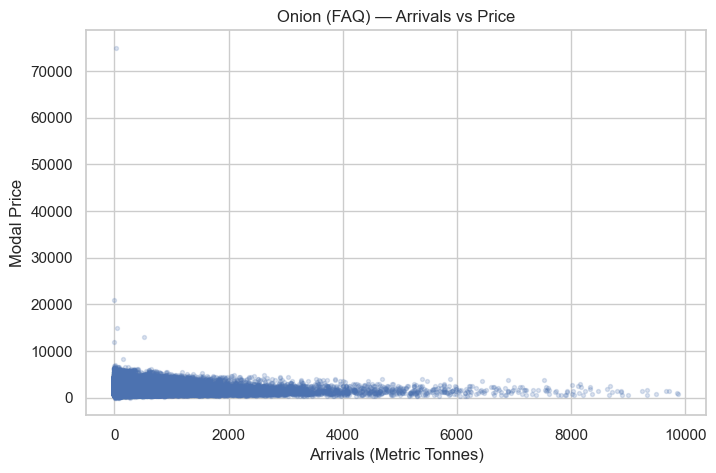

             arrivals  modal_price
arrivals      1.00000     -0.07595
modal_price  -0.07595      1.00000


In [334]:
# use the reliable subset from before
onion = df_reliable[(df_reliable.commodity_name == "Onion") & (df_reliable.grade == "FAQ")]

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(onion["arrivals"], onion["modal_price"], alpha=0.2, s=8)
plt.xlabel("Arrivals (Metric Tonnes)")
plt.ylabel("Modal Price")
plt.title("Onion (FAQ) — Arrivals vs Price")
plt.show()

print(onion[["arrivals","modal_price"]].corr())

             arrivals  modal_price
arrivals      1.00000     -0.07595
modal_price  -0.07595      1.00000
        report_date                                        market_name  \
1428594  2023-02-23                                   Junnar(Alephata)   
430741   2024-03-01                                        APMC Kalyan   
65494    2023-07-21                                         APMC Akola   
542717   2023-08-04                                      APMC Kolhapur   
431233   2025-09-30                                        APMC Kalyan   
797955   2021-02-01                                        APMC Nagpur   
478261   2024-11-10                                         APMC Karad   
274772   2023-06-28                                         APMC Dhule   
430894   2024-11-19                                        APMC Kalyan   
1694062  2024-11-27  Shivsiddha Govind Producer Company Ltd Sanchal...   

         arrivals  modal_price  
1428594      23.0      75000.0  
430741        

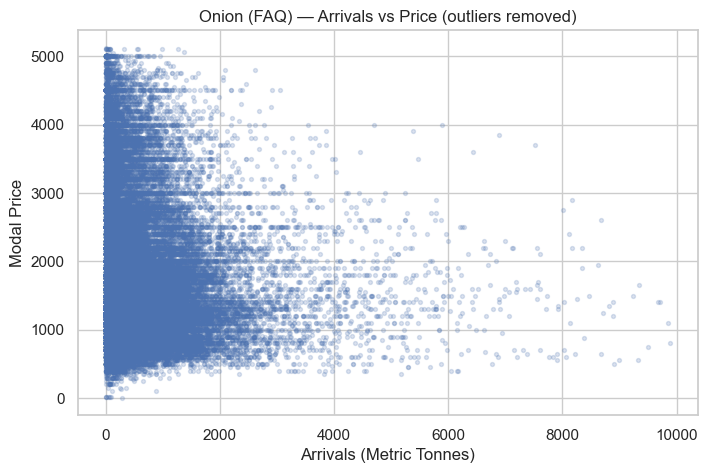

             arrivals  modal_price
arrivals     1.000000    -0.073436
modal_price -0.073436     1.000000


In [335]:
# check the actual correlation (you didn't paste this — run it)
print(onion[["arrivals","modal_price"]].corr())

# find what's driving the outliers
print(onion.sort_values("modal_price", ascending=False)[["report_date","market_name","arrivals","modal_price"]].head(10))

# re-plot with outliers filtered (using IQR or a sane price cap for onion)
onion_clean = onion[onion["modal_price"] < onion["modal_price"].quantile(0.995)]
plt.figure(figsize=(8,5))
plt.scatter(onion_clean["arrivals"], onion_clean["modal_price"], alpha=0.2, s=8)
plt.xlabel("Arrivals (Metric Tonnes)")
plt.ylabel("Modal Price")
plt.title("Onion (FAQ) — Arrivals vs Price (outliers removed)")
plt.show()

print(onion_clean[["arrivals","modal_price"]].corr())

In [336]:
extreme = df[df["modal_price"] > 100000].sort_values("modal_price", ascending=False)
print(extreme["commodity_name"].value_counts())
extreme[["report_date","market_name","commodity_name","min_price","max_price","modal_price"]].head(20)

commodity_name
Cardamom             861
Cashewnuts           123
Almond(Badam)        112
Cow                   15
She Buffalo           13
Cinamon(Dalchini)      6
Black pepper           3
Chili Red              1
Corriander seed        1
Guar                   1
Pomegranate            1
Mustard                1
Ginger(Dry)            1
Name: count, dtype: int64


,report_date,market_name,commodity_name,min_price,max_price,modal_price
427,2021-01-01,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
96695,2021-05-06,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
136634,2021-06-24,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
135489,2021-06-23,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
134338,2021-06-22,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
131645,2021-06-19,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
130648,2021-06-18,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
129472,2021-06-17,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
128258,2021-06-16,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
127018,2021-06-15,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0


In [337]:
# per-commodity price capping (99.5th percentile per commodity, not global — 
# since price scales differ wildly by commodity, e.g. Wheat vs Pomegranate)
def cap_outliers(group):
    cap = group["modal_price"].quantile(0.995)
    return group[group["modal_price"] <= cap]

df_reliable = df_reliable.groupby("commodity_name", group_keys=False).apply(cap_outliers)
print(df_reliable.shape)

(1696247, 16)


C:\Users\hp\AppData\Local\Temp\ipykernel_19636\200525608.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reliable = df_reliable.groupby("commodity_name", group_keys=False).apply(cap_outliers)


In [338]:
print(df[df["commodity_name"].isin(["Cow", "She Buffalo"])][["commodity_name","unit_of_price","min_price","max_price","modal_price"]].head(10))

      commodity_name unit_of_price  min_price  max_price  modal_price
3789             Cow      Rs./Unit    35000.0    60000.0      50000.0
3793     She Buffalo      Rs./Unit    30000.0    60000.0      45000.0
12001    She Buffalo      Rs./Unit    20000.0    63000.0      41500.0
12607            Cow      Rs./Unit    25000.0    68000.0      35000.0
18043    She Buffalo      Rs./Unit    20000.0    60000.0      40000.0
18691            Cow      Rs./Unit    25000.0    70000.0      35000.0
22866            Cow      Rs./Unit    30000.0    60000.0      45000.0
22869    She Buffalo      Rs./Unit    35000.0    60000.0      45000.0
25427            Cow      Rs./Unit    20000.0    70000.0      40000.0
30457    She Buffalo      Rs./Unit    20000.0    40000.0      30000.0


In [339]:
df_reliable = df_reliable[df_reliable["unit_of_price"] == "Rs./Quintal"]
print(df_reliable.shape)
print(df_reliable["commodity_name"].nunique(), "commodities remain")

# double check no other stray units exist
print(df_reliable["unit_of_price"].value_counts())

(1650419, 16)
104 commodities remain
unit_of_price
Rs./Quintal    1650419
Name: count, dtype: int64


In [340]:
df_reliable = df_reliable.sort_values(["market_name", "commodity_name", "variety", "grade", "report_date"])

df_reliable["year"] = df_reliable["report_date"].dt.year
df_reliable["month"] = df_reliable["report_date"].dt.month
df_reliable["day_of_week"] = df_reliable["report_date"].dt.dayofweek
df_reliable["week_of_year"] = df_reliable["report_date"].dt.isocalendar().week.astype(int)

# days since this exact series (market+commodity+variety+grade) last reported
grp_keys = ["market_name", "commodity_name", "variety", "grade"]
df_reliable["days_since_last_report"] = (
    df_reliable.groupby(grp_keys)["report_date"].diff().dt.days
)

print(df_reliable[["report_date","market_name","commodity_name","variety","grade","days_since_last_report"]].head(10))
print(df_reliable["days_since_last_report"].describe())

    report_date   market_name commodity_name           variety grade  \
62   2021-03-20  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
96   2021-11-13  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
285  2023-01-27  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
312  2023-03-01  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
313  2023-03-02  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
314  2023-03-03  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
322  2023-03-13  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
401  2023-11-17  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
403  2023-11-18  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
452  2024-01-30  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   

     days_since_last_report  
62                      NaN  
96                    238.0  
285                   440.0  
312                    33.0  
313                     1.0  
314                     1.0

In [341]:
import re
double_space = df_reliable["market_name"].str.contains(r"\s{2,}", regex=True, na=False)
print(double_space.sum(), "rows with internal double-spaces in market_name")
print(df_reliable.loc[double_space, "market_name"].unique()[:20])

12154 rows with internal double-spaces in market_name
['APMC  Chimur' 'APMC  Latur' 'APMC  Rajura' 'APMC  VASAI' 'APMC  Yawal']


In [342]:
df_reliable["market_name"] = df_reliable["market_name"].str.replace(r"\s+", " ", regex=True)

In [343]:
for name in ['APMC  Chimur', 'APMC  Latur', 'APMC  Rajura', 'APMC  VASAI', 'APMC  Yawal']:
    single_space = name.replace("  ", " ")
    print(name, "->", (df_reliable["market_name"] == single_space).sum(), "rows already exist as:", single_space)

APMC  Chimur -> 1686 rows already exist as: APMC Chimur
APMC  Latur -> 5341 rows already exist as: APMC Latur
APMC  Rajura -> 1760 rows already exist as: APMC Rajura
APMC  VASAI -> 1274 rows already exist as: APMC VASAI
APMC  Yawal -> 2093 rows already exist as: APMC Yawal


In [344]:
before = df_reliable["market_name"].nunique()

df_reliable["market_name"] = df_reliable["market_name"].str.replace(r"\s+", " ", regex=True)

after = df_reliable["market_name"].nunique()
print(f"markets: {before} -> {after}")  # should drop by exactly 5

# re-sort and recompute the gap feature now that series are correctly merged
df_reliable = df_reliable.sort_values(["market_name", "commodity_name", "variety", "grade", "report_date"])
grp_keys = ["market_name", "commodity_name", "variety", "grade"]
df_reliable["days_since_last_report"] = (
    df_reliable.groupby(grp_keys)["report_date"].diff().dt.days
)

# spot check one of the merged markets to confirm continuity
print(df_reliable[df_reliable.market_name == "APMC Chimur"]["days_since_last_report"].describe())

markets: 256 -> 256
count    1682.000000
mean        2.898930
std        17.987814
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       440.000000
Name: days_since_last_report, dtype: float64


In [345]:
for col in ["commodity_name", "variety", "grade"]:
    n = df_reliable[col].str.contains(r"\s{2,}", regex=True, na=False).sum()
    print(col, ":", n, "rows with internal double-spaces")

commodity_name : 0 rows with internal double-spaces
variety : 0 rows with internal double-spaces
grade : 0 rows with internal double-spaces


In [346]:
# direct check: do the double-space variants still exist at all?
remaining = df_reliable["market_name"].str.contains(r"\s{2,}", regex=True, na=False).sum()
print("Rows still containing double-space market names:", remaining)

# and confirm merge actually happened by checking one pair directly
print((df_reliable["market_name"] == "APMC Chimur").sum())
print((df_reliable["market_name"] == "APMC  Chimur").sum())  # should be 0 now

Rows still containing double-space market names: 0
1686
0


In [347]:
print(df_reliable["market_name"].nunique())

256


In [348]:
grp_keys = ["market_name", "commodity_name", "variety", "grade"]
grp = df_reliable.groupby(grp_keys)["modal_price"]

# lag features - price N reports ago (not N calendar days, since reporting is irregular)
df_reliable["price_lag_1"] = grp.shift(1)
df_reliable["price_lag_2"] = grp.shift(2)
df_reliable["price_lag_3"] = grp.shift(3)
df_reliable["price_lag_7"] = grp.shift(7)

# rolling stats over the last 7 / 30 reports (min_periods so early rows aren't all NaN)
df_reliable["price_roll_mean_7"] = grp.transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
df_reliable["price_roll_std_7"] = grp.transform(lambda s: s.shift(1).rolling(7, min_periods=3).std())
df_reliable["price_roll_mean_30"] = grp.transform(lambda s: s.shift(1).rolling(30, min_periods=5).mean())

print(df_reliable[["report_date","market_name","commodity_name","modal_price",
                    "price_lag_1","price_lag_7","price_roll_mean_7","price_roll_mean_30"]].head(15))
print(df_reliable[["price_lag_1","price_lag_7","price_roll_mean_7","price_roll_mean_30"]].isnull().sum())

      report_date   market_name commodity_name  modal_price  price_lag_1  \
12237  2021-01-14  APMC Aatpadi    Pomegranate      13500.0          NaN   
12238  2021-01-15  APMC Aatpadi    Pomegranate      13500.0      13500.0   
12239  2021-01-17  APMC Aatpadi    Pomegranate      15000.0      13500.0   
12240  2021-01-18  APMC Aatpadi    Pomegranate      12000.0      15000.0   
12241  2021-01-19  APMC Aatpadi    Pomegranate      12500.0      12000.0   
12242  2021-01-20  APMC Aatpadi    Pomegranate      13500.0      12500.0   
12243  2021-01-21  APMC Aatpadi    Pomegranate      13500.0      13500.0   
12244  2021-01-22  APMC Aatpadi    Pomegranate      10500.0      13500.0   
12245  2021-01-24  APMC Aatpadi    Pomegranate      12500.0      10500.0   
12246  2021-01-26  APMC Aatpadi    Pomegranate      15000.0      12500.0   
12248  2021-02-04  APMC Aatpadi    Pomegranate      18500.0      15000.0   
12255  2021-02-12  APMC Aatpadi    Pomegranate      18500.0      18500.0   
12257  2021-

In [349]:
# target: modal_price 7 reports ahead, for THIS series
df_reliable["target_price_7ahead"] = grp.shift(-7)

# also keep the date it corresponds to, so you can compute "days ahead" (since reporting is irregular)
df_reliable["target_date_7ahead"] = df_reliable.groupby(grp_keys)["report_date"].shift(-7)
df_reliable["horizon_days"] = (df_reliable["target_date_7ahead"] - df_reliable["report_date"]).dt.days

print(df_reliable[["report_date","target_date_7ahead","horizon_days","modal_price","target_price_7ahead"]].dropna().head(10))
print(df_reliable["horizon_days"].describe())

      report_date target_date_7ahead  horizon_days  modal_price  \
12237  2021-01-14         2021-01-22           8.0      13500.0   
12238  2021-01-15         2021-01-24           9.0      13500.0   
12239  2021-01-17         2021-01-26           9.0      15000.0   
12240  2021-01-18         2021-02-04          17.0      12000.0   
12241  2021-01-19         2021-02-12          24.0      12500.0   
12242  2021-01-20         2021-02-15          26.0      13500.0   
12243  2021-01-21         2021-02-19          29.0      13500.0   
12244  2021-01-22         2021-02-22          31.0      10500.0   
12245  2021-01-24         2021-02-23          30.0      12500.0   
12246  2021-01-26         2021-02-24          29.0      15000.0   

       target_price_7ahead  
12237              10500.0  
12238              12500.0  
12239              15000.0  
12240              18500.0  
12241              18500.0  
12242              18500.0  
12243              16500.0  
12244              18500.0  
1

In [350]:
# keep only rows where "7 reports ahead" is genuinely close to 7 calendar days
df_model = df_reliable[df_reliable["horizon_days"].between(5, 10)].copy()

print(df_model.shape, "rows kept out of", df_reliable.shape[0])
print(df_model["horizon_days"].value_counts().sort_index())

# drop rows with no target (last 7 reports of each series, and now-excluded long-horizon rows)
df_model = df_model.dropna(subset=["target_price_7ahead"])
print(df_model.shape)

(858336, 31) rows kept out of 1650419
horizon_days
7.0      71091
8.0     348373
9.0     261040
10.0    177832
Name: count, dtype: int64
(858336, 31)


In [351]:
split_date = df_model["report_date"].quantile(0.85)  # or pick a fixed date like "2025-06-01"
print("Split date:", split_date)

train = df_model[df_model["report_date"] < split_date]
test = df_model[df_model["report_date"] >= split_date]

print(train.shape, test.shape)
print(train["report_date"].max(), test["report_date"].min())

Split date: 2025-12-23 00:00:00
(729224, 31) (129112, 31)
2025-12-22 00:00:00 2025-12-23 00:00:00


In [352]:
df

,report_date,state_id,state_name,market_id,market_name,commodity_id,commodity_name,total_arrivals,arrivals,unit_of_arrivals,variety,grade,min_price,max_price,modal_price,unit_of_price
0,2021-01-01,20,Maharashtra,1349,APMC Chimur,15,Cotton,192.0,192.0,Metric Tonnes,Other,FAQ,5550.0,5625.0,5575.0,Rs./Quintal
1,2021-01-01,20,Maharashtra,1349,APMC Chimur,2,Paddy(Common),48.0,48.0,Metric Tonnes,Other,FAQ,2150.0,2250.0,2175.0,Rs./Quintal
2,2021-01-01,20,Maharashtra,1933,APMC Rajura,13,Soyabean,14.0,14.0,Metric Tonnes,Yellow,FAQ,3895.0,4210.0,4095.0,Rs./Quintal
3,2021-01-01,20,Maharashtra,2048,APMC Aarni,45,Red gram/Arhar/Tur(whole),14.0,14.0,Metric Tonnes,Other,FAQ,5500.0,5800.0,5600.0,Rs./Quintal
4,2021-01-01,20,Maharashtra,1901,APMC Aatpadi,160,Pomegranate,50.0,50.0,Metric Tonnes,Other,FAQ,2000.0,40000.0,21000.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967776,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),131,Cucumbar(Kheera),1.2,1.2,Metric Tonnes,Other,Local,1400.0,2200.0,1800.0,Rs./Quintal
1967777,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),23,Onion,3.3,3.3,Metric Tonnes,Local,Local,2500.0,4700.0,3600.0,Rs./Quintal
1967778,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),133,Raddish,600.0,600.0,Metric Tonnes,Other,Local,7.0,9.0,8.0,Rs./Quintal
1967779,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),290,Spinach,650.0,650.0,Metric Tonnes,Other,Local,7.0,9.0,8.0,Rs./Quintal


In [353]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1967363 entries, 0 to 1967780
Data columns (total 16 columns):
 #   Column            Dtype         
---  ------            -----         
 0   report_date       datetime64[ns]
 1   state_id          int64         
 2   state_name        object        
 3   market_id         int64         
 4   market_name       object        
 5   commodity_id      int64         
 6   commodity_name    object        
 7   total_arrivals    float64       
 8   arrivals          float64       
 9   unit_of_arrivals  object        
 10  variety           object        
 11  grade             object        
 12  min_price         float64       
 13  max_price         float64       
 14  modal_price       float64       
 15  unit_of_price     object        
dtypes: datetime64[ns](1), float64(5), int64(3), object(7)
memory usage: 255.2+ MB


In [354]:
keep_cols = [
    "report_date",
    "market_id",
    "market_name",
    "commodity_id",
    "commodity_name",
    "arrivals",
    "variety",
    "grade",
    "min_price",
    "modal_price",
    "max_price"
]

df_clean = df[keep_cols].copy()

df_clean.to_csv(
    "../processed/maharashtra_prices_clean.csv",
    index=False
)

print(df_clean.shape)
print("Saved successfully!")

(1967363, 11)
Saved successfully!
